In [26]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from scipy.stats import norm

In [8]:
def fnormal1var(x, mu, sigma):
    return 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (x - mu)**2 / (2 * sigma**2))

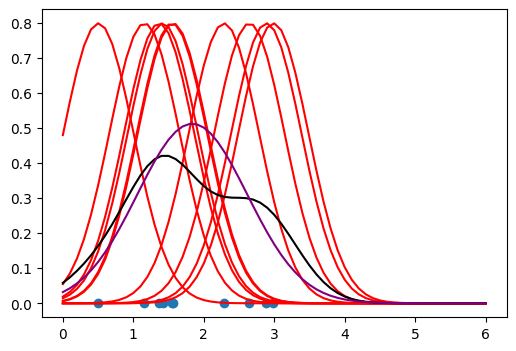

In [15]:
N1 = 10
xc = np.random.normal(loc=2, scale = 1, size = (N1,1))

plt.figure(figsize=(6,4))

plt.scatter(x=xc, y = np.zeros_like(xc))

xrange = np.arange(0,6.1,0.1)

fall = np.zeros_like(xrange)

for x in xc:

    yrange = fnormal1var(xrange, x, 0.5)

    plt.plot(xrange,yrange, color = 'red')

    fall += yrange

fall = fall/N1
plt.plot(xrange, fall, color = 'black')

mygauss = fnormal1var(xrange, np.mean(xc), np.std(xc))
plt.plot(xrange, mygauss, color = 'purple')
plt.show()

## Dados bimodais

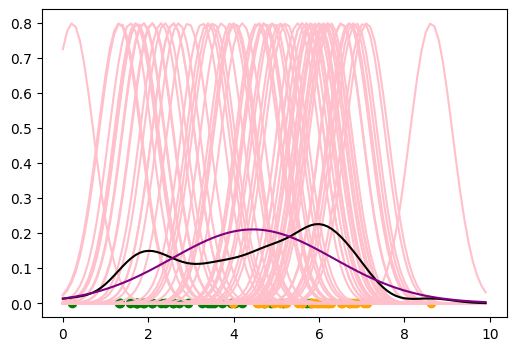

In [24]:
N1 = 30
xc1 = np.random.normal(loc=3, scale = 1, size = (N1,1))

N1 = 30
xc2 = np.random.normal(loc=6, scale = 1, size = (N1,1))

plt.figure(figsize=(6,4))

plt.scatter(x=xc1, y = np.zeros_like(xc1), color = 'green')
plt.scatter(x=xc2, y = np.zeros_like(xc2), color = 'orange')

xrange = np.arange(0,10,0.1)
xall = np.vstack((xc1,xc2))
fall = np.zeros_like(xrange)

for x in xall:

    yrange = fnormal1var(xrange, x, 0.5)

    plt.plot(xrange,yrange, color = 'pink')

    fall += yrange

fall = fall/(2*N1)
plt.plot(xrange, fall, color = 'black')

mygauss = fnormal1var(xrange, np.mean(xall), np.std(xall))
plt.plot(xrange, mygauss, color = 'purple')
plt.show()

In [27]:
def fnormal1var(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

N1 = 30
xc1 = np.random.normal(loc=3, scale=1, size=(N1, 1))
xc2 = np.random.normal(loc=6, scale=1, size=(N1, 1))

xrange = np.arange(0, 10, 0.1)
xall = np.vstack((xc1, xc2))
fall = np.zeros_like(xrange)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=xc1.flatten(), y=np.zeros_like(xc1).flatten(),
    mode='markers', name='xc1', marker=dict(color='green')
))

fig.add_trace(go.Scatter(
    x=xc2.flatten(), y=np.zeros_like(xc2).flatten(),
    mode='markers', name='xc2', marker=dict(color='orange')
))

for x in xall:
    yrange = fnormal1var(xrange, x, 0.5)
    fig.add_trace(go.Scatter(
        x=xrange, y=yrange,
        mode='lines', line=dict(color='pink', width=1),
        opacity=0.3, showlegend=False
    ))
    fall += yrange

fall = fall / (2 * N1)
fig.add_trace(go.Scatter(
    x=xrange, y=fall,
    mode='lines', line=dict(color='black', width=2),
    name='Média densidades'
))

mygauss = fnormal1var(xrange, np.mean(xall), np.std(xall))
fig.add_trace(go.Scatter(
    x=xrange, y=mygauss,
    mode='lines', line=dict(color='purple', width=2, dash='dot'),
    name='Gauss única'
))

fig.update_layout(
    title="Distribuições Normais Interativas",
    xaxis_title="x",
    yaxis_title="Densidade",
    template="plotly_white"
)

fig.show()


## KDE Multivariado

In [28]:
def fnormal2var(m1, m2, s1, s2, x1, x2):
    fNx1 = np.asmatrix(fnormal1var(m1, s1, x1))
    fNx2 = np.asmatrix(fnormal1var(m2, s2, x2))
    pxy = fNx1 * fNx2
    return pxy